In [31]:
import os

import pandas as pd
from tqdm import tqdm

tqdm.pandas()

# 1. Load output.jsonl and completions, then convert to training data

In [32]:
import json
from glob import glob

from tqdm import tqdm

JSONL_PATH = '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/output.jsonl'
OUTPUT_DIR = os.path.dirname(JSONL_PATH)


def load_last_completion_messages(output_dir: str, instance_id: str):
    """Load messages and tools from the last LLM completion file.

    The completion file's messages already contain oracle-revised content
    for all previous turns (the revised action is what gets executed,
    so the solver sees it in context). We only take the messages and tools
    here — the response will come from output.jsonl's history.
    """
    glob_path = os.path.join(output_dir, 'llm_completions', instance_id, '*.json')
    files = sorted(glob(glob_path))
    if not files:
        return None
    with open(files[-1], 'r') as f:
        result = json.load(f)
    return {
        'messages': result['messages'],
        'tools': result['kwargs'].get('tools', []),
    }


def get_last_model_response(history: list[dict]):
    """Extract model_response from the last agent action in output.jsonl history.

    Each agent action stores the fn-call format ModelResponse in
    tool_call_metadata.model_response. For oracle-revised steps,
    this contains the oracle's response (model='oracle-guided');
    for solver-selected steps, it contains the solver's response.
    """
    for h in reversed(history):
        if h.get('source') != 'agent':
            continue
        # Try both top-level and nested in args (output.jsonl format varies)
        tcm = h.get('tool_call_metadata') or h.get('args', {}).get('tool_call_metadata')
        if not tcm:
            if h.get('action') == 'message':
                continue  # MessageAction has no model_response
            continue
        mr = tcm.get('model_response')
        if mr and mr.get('choices'):
            return mr['choices'][0]['message']
    return None


# Read output.jsonl and construct correct completions
data = []
with open(JSONL_PATH, 'r') as f:
    for line in tqdm(f, desc='Processing output.jsonl'):
        raw_data = json.loads(line)
        instance_id = raw_data['instance_id']
        history = raw_data.get('history') or []

        # Load completion file (messages + tools, NOT response)
        completion_data = load_last_completion_messages(OUTPUT_DIR, instance_id)
        if completion_data is None:
            data.append({
                'instance_id': instance_id,
                'messages': None,
                'git_patch': raw_data.get('test_result', {}).get('git_patch', ''),
                'tools': None,
            })
            continue

        # Get the actual last response from output.jsonl history
        # This is the oracle-revised response (or solver's if it was selected)
        last_response = get_last_model_response(history)

        # Build messages: completion file messages + correct last response
        messages = list(completion_data['messages'])
        if last_response is not None:
            resp_msg = {
                'role': last_response.get('role', 'assistant'),
                'content': last_response.get('content') or '',
            }
            if last_response.get('tool_calls'):
                resp_msg['tool_calls'] = last_response['tool_calls']
            messages.append(resp_msg)

        data.append({
            'instance_id': instance_id,
            'messages': messages if last_response is not None else None,
            'git_patch': raw_data.get('test_result', {}).get('git_patch', ''),
            'tools': completion_data.get('tools'),
        })

df = pd.DataFrame(data)
print(f'#total amount of data={len(df)}')
df = df[~df['messages'].isna()]
print(f'#total amount of data after removing nan={len(df)}')

# Show how many end with finish
finish_count = sum(
    1 for msgs in df['messages']
    if msgs and any(
        tc['function']['name'] == 'finish'
        for tc in (msgs[-1].get('tool_calls') or [])
    )
)
print(f'#trajectories ending with finish: {finish_count}')

Processing output.jsonl: 812it [00:06, 121.53it/s]

#total amount of data=812
#total amount of data after removing nan=794
#trajectories ending with finish: 659


## Filter

In [33]:
def _contains_multiple_tool_calls(messages: list[dict]) -> bool:
    return any(
        message.get('tool_calls') and len(message['tool_calls']) > 1
        for message in messages
    )


df['contains_multiple_tool_calls'] = df['messages'].apply(_contains_multiple_tool_calls)
display(df['contains_multiple_tool_calls'].value_counts())

contains_multiple_tool_calls
False    628
True     166
Name: count, dtype: int64

In [34]:
import copy

# Convert function calling messages to non-function calling messages
from openhands.llm.fn_call_converter import (
    FunctionCallConversionError,
    convert_fncall_messages_to_non_fncall_messages,
    convert_from_multiple_tool_calls_to_single_tool_call_messages,
)

total_failed = 0

# Set to True for reasoning models (e.g. GLM-5 with glm45 parser)
# that split thinking into a separate 'reasoning_content' field.
# When True, reasoning_content is merged into content before conversion.
MERGE_REASONING_CONTENT = True


def _ensure_content_key(messages: list[dict]) -> list[dict]:
    """Ensure every message has a 'content' key (fn_call_converter requires it)."""
    for msg in messages:
        if 'content' not in msg:
            msg['content'] = ''
        elif msg['content'] is None:
            msg['content'] = ''
    return messages


def _convert_messages(messages: list[dict], tools: list[dict]) -> list[dict]:
    global total_failed
    message_copy = copy.deepcopy(messages)
    _ensure_content_key(message_copy)
    try:
        return convert_fncall_messages_to_non_fncall_messages(
            message_copy, tools,
            add_in_context_learning_example=False,
            merge_reasoning_content=MERGE_REASONING_CONTENT,
        )
    except FunctionCallConversionError:
        total_failed += 1
        return None


df['converted_messages'] = df.apply(
    lambda row: convert_from_multiple_tool_calls_to_single_tool_call_messages(
        _ensure_content_key(copy.deepcopy(row['messages'])), ignore_final_tool_result=True
    ),
    axis=1,
)
df['nonfncall_messages'] = df.apply(
    lambda row: _convert_messages(row['converted_messages'], row['tools']), axis=1
)
print('total nan', df['nonfncall_messages'].isna().sum())
df = df[~df['nonfncall_messages'].isna()]
print(f'Total failed: {total_failed}')
print(f'MERGE_REASONING_CONTENT={MERGE_REASONING_CONTENT}')

total nan 0
Total failed: 0


## Tokenization

In [35]:
from pandarallel import pandarallel
from transformers import AutoTokenizer

os.environ['TOKENIZERS_PARALLELISM'] = 'true'
pandarallel.initialize(progress_bar=True, verbose=1, nb_workers=16)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')


def _normalize_and_tokenize(messages):
    normalized = []
    for msg in messages:
        m = dict(msg)
        if isinstance(m.get('content'), list):
            m['content'] = '\n'.join(
                part['text'] for part in m['content'] if part.get('type') == 'text'
            )
        normalized.append(m)
    return len(tokenizer.apply_chat_template(normalized))


df['n_tokens'] = df['nonfncall_messages'].parallel_apply(_normalize_and_tokenize)

In [36]:
print(f'BEFORE: #total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'AFTER(truncated to 128k): #total={len(df_selected)}')

BEFORE: #total=794
AFTER(truncated to 128k): #total=794


In [37]:
df_selected['n_tokens'].describe()

count       794.000000
mean      47542.304786
std       15082.371762
min       18843.000000
25%       36303.250000
50%       44780.000000
75%       56332.250000
max      124953.000000
Name: n_tokens, dtype: float64

count       794.000000
mean      47542.304786
std       15082.371762
min       18843.000000
25%       36303.250000
50%       44780.000000
75%       56332.250000
max      124953.000000
Name: n_tokens, dtype: float64

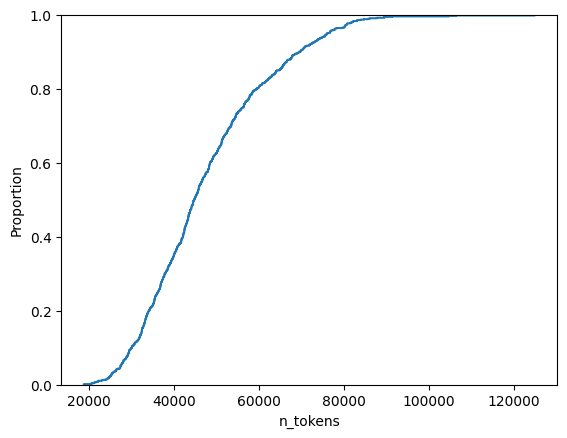

#total=794
#selected=794


count       794.000000
mean      47542.304786
std       15082.371762
min       18843.000000
25%       36303.250000
50%       44780.000000
75%       56332.250000
max      124953.000000
Name: n_tokens, dtype: float64

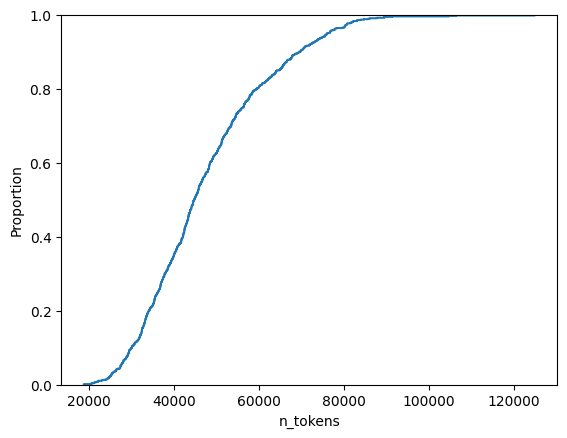

In [38]:
# ecdf of n_tokens
import matplotlib.pyplot as plt
import seaborn as sns

display(df['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df)
plt.show()

print(f'#total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'#selected={len(df_selected)}')
display(df_selected['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df_selected)
plt.show()

In [39]:
def _normalize_to_sft_format(messages):
    """Convert messages to SWE-Gym/OpenHands-SFT-Trajectories format.

    Target: each message has only 'role' (str) and 'content' (str).
    """
    normalized = []
    for msg in messages:
        content = msg.get('content', '') or ''
        if isinstance(content, list):
            content = '\n'.join(
                part['text'] for part in content if part.get('type') == 'text'
            )
        normalized.append({'role': msg['role'], 'content': content})
    return normalized


df_selected = df_selected.copy()
df_selected['nonfncall_messages'] = df_selected['nonfncall_messages'].apply(_normalize_to_sft_format)
print('Normalized messages to SFT format (role + content strings only)')

Normalized messages to SFT format (role + content strings only)


# Save All Messages for SFT

In [40]:
save_dir = os.path.join(OUTPUT_DIR, 'sft')
os.makedirs(save_dir, exist_ok=True)

# Save all
out_path = os.path.join(
    save_dir,
    f'oracle_traj_128k_swegym_all_{len(df_selected)}i.jsonl',
)
df_selected[['nonfncall_messages']].rename(
    columns={'nonfncall_messages': 'messages'}
).to_json(
    out_path,
    lines=True,
    orient='records',
)
print(f'Saved {len(df_selected)} trajectories to {out_path}')


Saved 794 trajectories to /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/sft/oracle_traj_128k_swegym_all_794i.jsonl


In [41]:

# Save filtered subset (editvalid_or_fact_ge70)
FILTER_JSON = '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_analysis/oracle_guided_analysis/filtered_instances/editvalid_or_fact_ge70_593_20260418_064220.json'

with open(FILTER_JSON) as f:
    filter_data = json.load(f)

filter_ids = set(filter_data['instance_ids'])
filter_tag = filter_data['tag']

df_filtered = df_selected[df_selected['instance_id'].isin(filter_ids)]
print(f'\nFilter "{filter_tag}": {len(df_filtered)}/{len(df_selected)} instances matched')

out_path_filtered = os.path.join(
    save_dir,
    f'oracle_traj_128k_swegym_{filter_tag}_{len(df_filtered)}i.jsonl',
)
df_filtered[['nonfncall_messages']].rename(
    columns={'nonfncall_messages': 'messages'}
).to_json(
    out_path_filtered,
    lines=True,
    orient='records',
)
print(f'Saved {len(df_filtered)} trajectories to {out_path_filtered}')


Filter "editvalid_or_fact_ge70": 593/794 instances matched
Saved 593 trajectories to /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/sft/oracle_traj_128k_swegym_editvalid_or_fact_ge70_593i.jsonl
